# MDMR Structure Learning on Simulated DAGs

This notebook evaluates MDMR hill-climbing structure learning on two simulated DAG structures:
- 4-variable DAG (Y3->Y1, Y3->Y4, Y1->Y2, Y4->Y2)
- 5-variable DAG (Y1->Y2, Y1->Y3, Y2->Y4, Y3->Y4, Y2->Y5)

We compute evaluation metrics including:
- Connection accuracy
- Sensitivity (true positive rate)
- Specificity (true negative rate)
- Positive Predictive Value (PPV)
- Negative Predictive Value (NPV)
- Directional accuracy

In [1]:
library(mdmr)
library(reshape2)
library(dplyr)

# Load simulation utilities
source("simulation_utils.R")


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## Load Simulated Data

Load the simulated data files that were generated by `simulate_dags.py`.

In [2]:
# Define data directory
data_dir <- "./data/"

# Load 4-variable data
data_4var <- read.csv(file.path(data_dir, "dag_4var_simulated.csv"))
true_adj_4var <- as.matrix(read.csv(
    file.path(data_dir, "dag_4var_true_adjacency.csv"), 
    row.names = 1
))

# Load 5-variable data
data_5var <- read.csv(file.path(data_dir, "dag_5var_simulated.csv"))
true_adj_5var <- as.matrix(read.csv(
    file.path(data_dir, "dag_5var_true_adjacency.csv"), 
    row.names = 1
))

cat("4-variable data shape:", nrow(data_4var), "x", ncol(data_4var), "\n")
cat("4-variable true adjacency shape:", nrow(true_adj_4var), "x", ncol(true_adj_4var), "\n")
cat("\n5-variable data shape:", nrow(data_5var), "x", ncol(data_5var), "\n")
cat("5-variable true adjacency shape:", nrow(true_adj_5var), "x", ncol(true_adj_5var), "\n")

4-variable data shape: 200 x 4 
4-variable true adjacency shape: 4 x 4 

5-variable data shape: 200 x 5 
5-variable true adjacency shape: 5 x 5 


## 4-Variable DAG: MDMR Structure Learning

In [3]:
# Run MDMR hill-climbing on 4-variable data using mdmr package
cat("Running MDMR hill-climbing on 4-variable DAG...\n")
start_time <- Sys.time()

# Fit MDM model using mdmr package
res_4var <- mdm(data_input = data_4var, method = "hc")

# Extract adjacency matrix from result
adj_matrix_4var <- res_4var$adj_mat

end_time <- Sys.time()
time_4var <- as.numeric(difftime(end_time, start_time, units = "secs"))

cat("\nTime taken:", round(time_4var, 2), "seconds\n")
cat("\nEstimated adjacency matrix:\n")
print(adj_matrix_4var)

Running MDMR hill-climbing on 4-variable DAG...


Running bnlearn::hc() with MDM custom score...




Time taken: 4.52 seconds

Estimated adjacency matrix:
   Y1 Y2 Y3 Y4
Y1  0  1  0  0
Y2  0  0  0  0
Y3  1  0  0  1
Y4  0  1  0  0


In [4]:
# Compute metrics for 4-variable DAG
metrics_4var <- compute_metrics(true_adj_4var, adj_matrix_4var)

cat("Evaluation Metrics for 4-Variable DAG:\n")
cat("  Accuracy:", round(metrics_4var$accuracy, 4), "\n")
cat("  Sensitivity:", round(metrics_4var$sensitivity, 4), "\n")
cat("  Specificity:", round(metrics_4var$specificity, 4), "\n")
cat("  PPV:", round(metrics_4var$ppv, 4), "\n")
cat("  NPV:", round(metrics_4var$npv, 4), "\n")
cat("  Directional Accuracy:", round(metrics_4var$directional_accuracy, 4), "\n")

# Discount factors (from mdm result)
cat("\nDiscount Factors:\n")
df_4var <- res_4var$DF$DF_hat
for (i in seq_along(df_4var)) {
    cat("  ", names(df_4var)[i], ":", round(df_4var[i], 4), "\n")
}

# Number of edges
cat("\nNumber of edges (estimated):", sum(adj_matrix_4var), "\n")
cat("Number of edges (true):", sum(true_adj_4var), "\n")

Evaluation Metrics for 4-Variable DAG:
  Accuracy: 1 
  Sensitivity: 1 
  Specificity: 1 
  PPV: 1 
  NPV: 1 
  Directional Accuracy: 1 

Discount Factors:
   : 0.86 
   : 0.63 
   : 1 
   : 0.85 

Number of edges (estimated): 4 
Number of edges (true): 4 


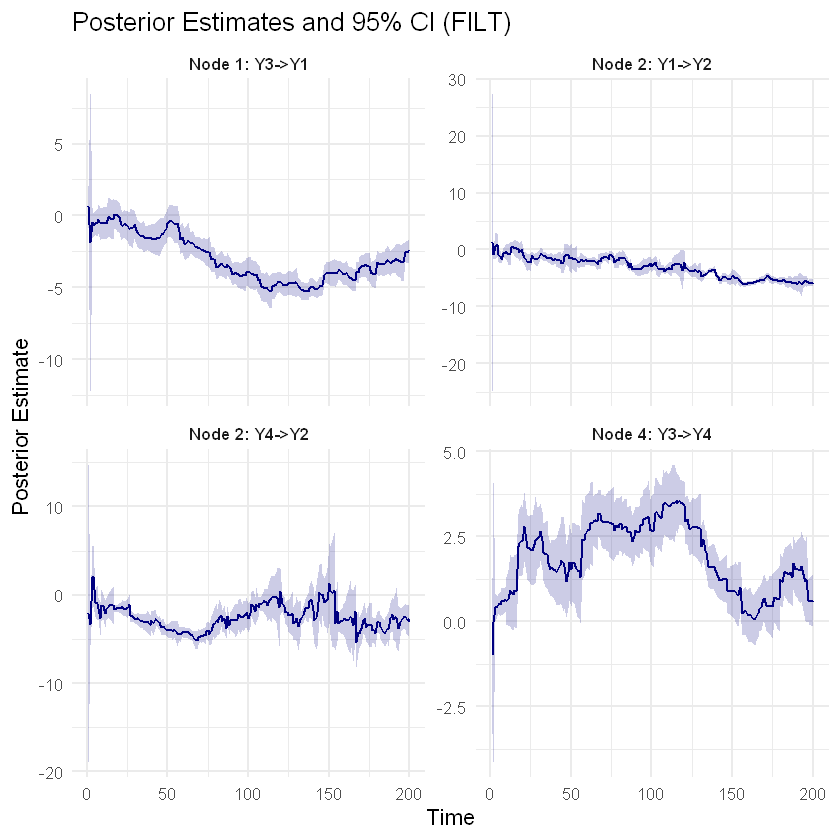

In [9]:
plot_arcs(res_4var, type = "connections", distribution = "filt", ci_level = 0.95)

## 5-Variable DAG: MDMR Structure Learning

In [5]:
# Run MDMR hill-climbing on 5-variable data using mdmr package
cat("Running MDMR hill-climbing on 5-variable DAG...\n")
start_time <- Sys.time()

# Fit MDM model using mdmr package
res_5var <- mdm(data_input = data_5var, method = "hc")

# Extract adjacency matrix from result
adj_matrix_5var <- res_5var$adj_mat

end_time <- Sys.time()
time_5var <- as.numeric(difftime(end_time, start_time, units = "secs"))

cat("\nTime taken:", round(time_5var, 2), "seconds\n")
cat("\nEstimated adjacency matrix:\n")
print(adj_matrix_5var)

Running MDMR hill-climbing on 5-variable DAG...


Running bnlearn::hc() with MDM custom score...




Time taken: 5.94 seconds

Estimated adjacency matrix:
   Y1 Y2 Y3 Y4 Y5
Y1  0  1  1  0  0
Y2  0  0  0  1  1
Y3  0  0  0  1  0
Y4  0  0  0  0  0
Y5  0  0  0  0  0


In [6]:
# Compute metrics for 5-variable DAG
metrics_5var <- compute_metrics(true_adj_5var, adj_matrix_5var)

cat("Evaluation Metrics for 5-Variable DAG:\n")
cat("  Accuracy:", round(metrics_5var$accuracy, 4), "\n")
cat("  Sensitivity:", round(metrics_5var$sensitivity, 4), "\n")
cat("  Specificity:", round(metrics_5var$specificity, 4), "\n")
cat("  PPV:", round(metrics_5var$ppv, 4), "\n")
cat("  NPV:", round(metrics_5var$npv, 4), "\n")
cat("  Directional Accuracy:", round(metrics_5var$directional_accuracy, 4), "\n")

# Discount factors (from mdm result)
cat("\nDiscount Factors:\n")
df_5var <- res_5var$DF$DF_hat
for (i in seq_along(df_5var)) {
    cat("  ", names(df_5var)[i], ":", round(df_5var[i], 4), "\n")
}

# Number of edges
cat("\nNumber of edges (estimated):", sum(adj_matrix_5var), "\n")
cat("Number of edges (true):", sum(true_adj_5var), "\n")

Evaluation Metrics for 5-Variable DAG:
  Accuracy: 1 


  Sensitivity: 1 
  Specificity: 1 
  PPV: 1 
  NPV: 1 
  Directional Accuracy: 1 

Discount Factors:
   : 1 
   : 0.84 
   : 0.79 
   : 0.65 
   : 0.59 

Number of edges (estimated): 5 
Number of edges (true): 5 


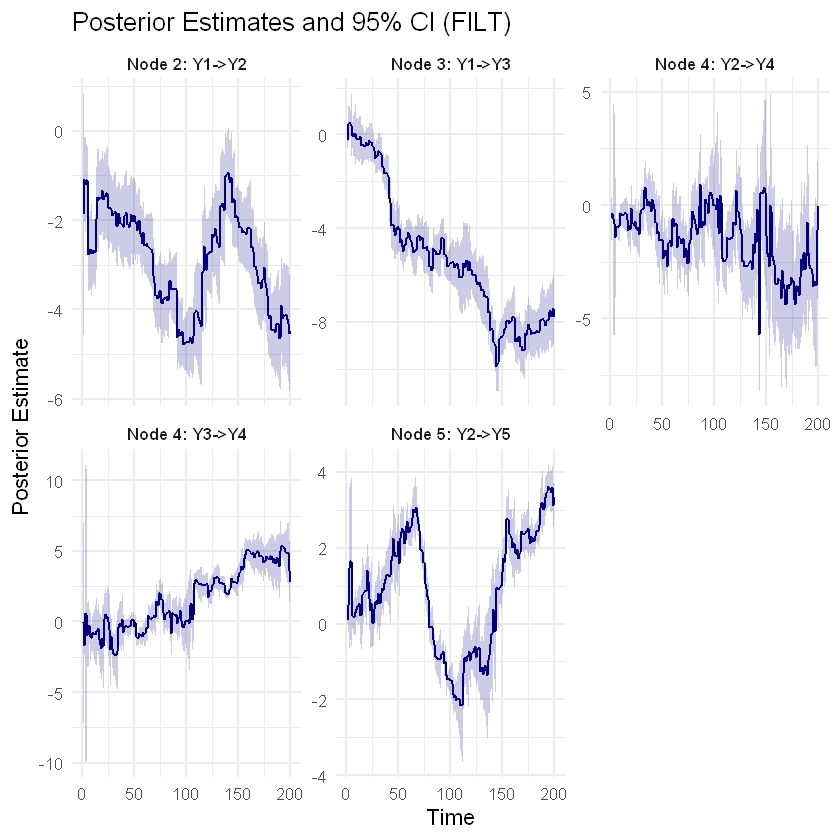

In [7]:
plot_arcs(res_5var, type = "connections", distribution = "filt", ci_level = 0.95)

## Save Results

Save results to CSV files for comparison with MDMP results.

In [8]:
# Prepare results dataframes
results_4var <- data.frame(
    metric = c('accuracy', 'sensitivity', 'specificity', 'ppv', 'npv', 'directional_accuracy',
               'num_edges_estimated', 'num_edges_true', 'computation_time'),
    value = c(
        metrics_4var$accuracy,
        metrics_4var$sensitivity,
        metrics_4var$specificity,
        metrics_4var$ppv,
        metrics_4var$npv,
        metrics_4var$directional_accuracy,
        sum(adj_matrix_4var),
        sum(true_adj_4var),
        time_4var
    ),
    dag = '4var',
    method = 'mdmr'
)

results_5var <- data.frame(
    metric = c('accuracy', 'sensitivity', 'specificity', 'ppv', 'npv', 'directional_accuracy',
               'num_edges_estimated', 'num_edges_true', 'computation_time'),
    value = c(
        metrics_5var$accuracy,
        metrics_5var$sensitivity,
        metrics_5var$specificity,
        metrics_5var$ppv,
        metrics_5var$npv,
        metrics_5var$directional_accuracy,
        sum(adj_matrix_5var),
        sum(true_adj_5var),
        time_5var
    ),
    dag = '5var',
    method = 'mdmr'
)

# Combine and save
results_mdmr <- rbind(results_4var, results_5var)
write.csv(results_mdmr, file.path(data_dir, "mdmr_results.csv"), row.names = FALSE)

# Save adjacency matrices
write.csv(adj_matrix_4var, file.path(data_dir, "mdmr_adjacency_4var.csv"), row.names = TRUE)
write.csv(adj_matrix_5var, file.path(data_dir, "mdmr_adjacency_5var.csv"), row.names = TRUE)

cat("Results saved to:", file.path(data_dir, "mdmr_results.csv"), "\n")

Results saved to: ./data//mdmr_results.csv 
